<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/notebooks/09_radial_profile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

Data Shape: (11, 126, 121)


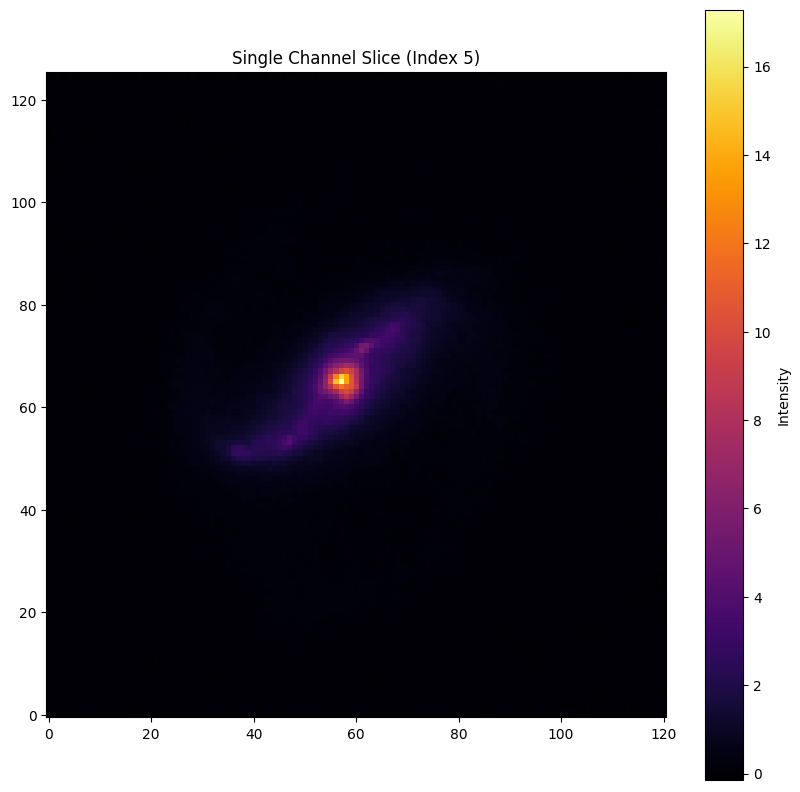

In [ ]:

filename = "barred1.fits"
hdul = fits.open(filename)

header = hdul[0].header
data = hdul[0].data

print(f"Data Shape: {data.shape}")

slice_index = data.shape[0] // 2
plt.figure(figsize=(10, 10))
plt.imshow(data[slice_index, :, :], origin='lower', cmap='inferno')
plt.title(f"Single Channel Slice (Index {slice_index})")
plt.colorbar(label="Intensity")
plt.show()


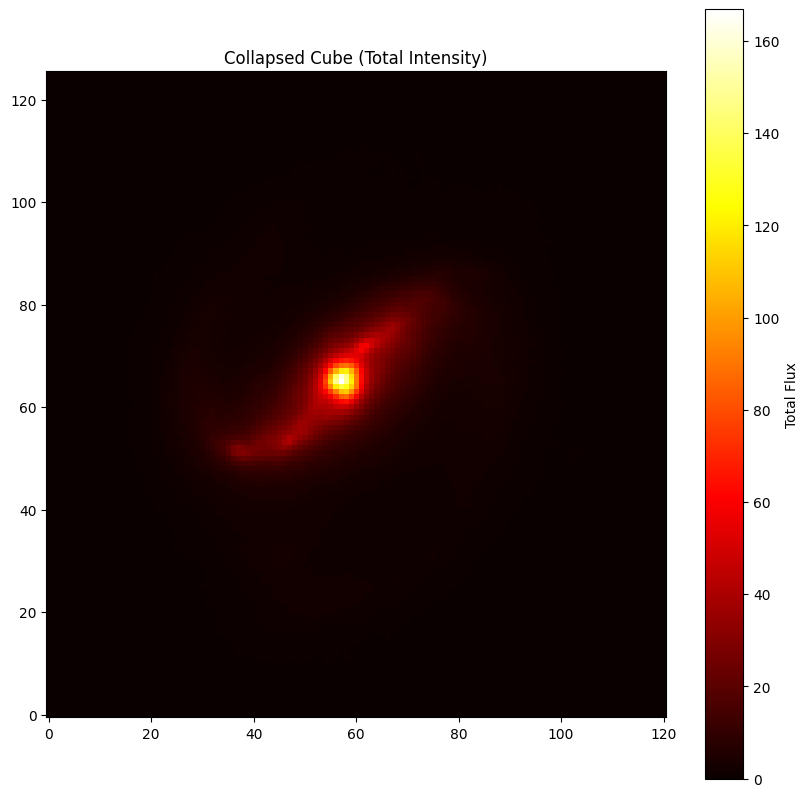

In [ ]:
total_intensity = np.sum(data, axis=0)

plt.figure(figsize=(10, 10))
plt.imshow(total_intensity, origin='lower', cmap='hot')
plt.title("Collapsed Cube (Total Intensity)")
plt.colorbar(label="Total Flux")
plt.show()

hdul.close()

Center found at: (57, 65)


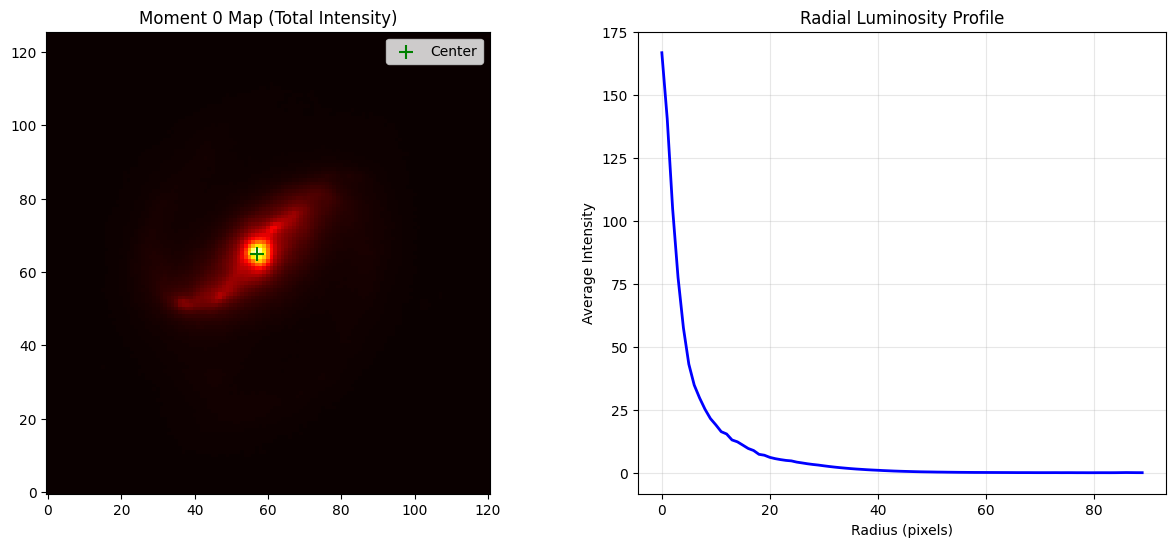

In [ ]:

collapsedCube = np.sum(data, axis=0)

#finds brightest pixel than turns it into coordinates i can use
y_center, x_center = np.unravel_index(np.argmax(collapsedCube), collapsedCube.shape)
print(f"Cente: ({x_center}, {y_center})")

def calculate_radial_profile(image, center_x, center_y):
    #creates the grids
    y, x = np.indices(image.shape)
    #formula for the distances
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2)

    max_radius = int(r.max())
    radial_profile = []

    for radius in range(max_radius):

        #gets only the pixels within that radius.
        ring_mask = (r >= radius) & (r < radius + 1)

        if np.sum(ring_mask) > 0:
            avg_brightness = np.mean(image[ring_mask])#averages the brightness
        else:
            avg_brightness = 0

        radial_profile.append(avg_brightness)

    return np.array(radial_profile)


profile = calculate_radial_profile(collapsedCube, x_center, y_center)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].imshow(collapsedCube, origin='lower', cmap='hot')
ax[0].scatter(x_center, y_center, color='green', marker='+', s=100, label='Center')
ax[0].set_title("Moment 0 Map (Total Intensity)")
ax[0].legend()

ax[1].plot(profile, color='blue', linewidth=2)
ax[1].set_xlabel("Radius (pixels)")
ax[1].set_ylabel("Average Intensity")
ax[1].set_title("Radial Luminosity Profile")
ax[1].grid(True, alpha=0.3)

plt.show()